In [13]:
import pandas as pd

df= pd.read_csv("data/weather.csv")
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [3]:
print(type(df))
print(df.shape)
print(df.columns)
print(df.info())

<class 'pandas.DataFrame'>
(1461, 6)
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 68.6 KB
None


In [4]:
df[["date","temp_max","temp_min"]]

,date,temp_max,temp_min
0,2012-01-01,12.8,5.0
1,2012-01-02,10.6,2.8
2,2012-01-03,11.7,7.2
3,2012-01-04,12.2,5.6
4,2012-01-05,8.9,2.8
...,...,...,...
1456,2015-12-27,4.4,1.7
1457,2015-12-28,5.0,1.7
1458,2015-12-29,7.2,0.6
1459,2015-12-30,5.6,-1.0


In [5]:
df.loc[0]
#根据标签获取标签为1的数据(开头不一定是几），返回值是一个series对象

date             2012-01-01
precipitation           0.0
temp_max               12.8
temp_min                5.0
wind                    4.7
weather             drizzle
Name: 0, dtype: object

In [6]:
df.loc[[1,10,100]]

,date,precipitation,temp_max,temp_min,wind,weather
1,2012-01-02,10.9,10.6,2.8,4.5,rain
10,2012-01-11,0.0,6.1,-1.1,5.1,sun
100,2012-04-10,0.0,17.8,8.9,3.2,rain


In [7]:
df.iloc[0]
# iloc是按索引(开头为0)

date             2012-01-01
precipitation           0.0
temp_max               12.8
temp_min                5.0
wind                    4.7
weather             drizzle
Name: 0, dtype: object

In [8]:
df["month"]= pd.to_datetime(df["date"]).dt.to_period("M").astype("str")

#得到分组对象
df_group_data=df.groupby("month")

month_temp= df_group_data[["temp_max","temp_min"]]

month_mean= month_temp.mean()

month_mean

,temp_max,temp_min
month,,
2012-01,7.054839,1.541935
2012-02,9.275862,3.203448
2012-03,9.554839,2.838710
2012-04,14.873333,5.993333
2012-05,17.661290,8.190323
2012-06,18.693333,10.480000
2012-07,22.906452,12.932258
2012-08,25.858065,14.009677
2012-09,22.880000,11.243333


In [9]:
get_data=df.groupby("month")[["temp_max","temp_min"]].mean()
get_data

,temp_max,temp_min
month,,
2012-01,7.054839,1.541935
2012-02,9.275862,3.203448
2012-03,9.554839,2.838710
2012-04,14.873333,5.993333
2012-05,17.661290,8.190323
2012-06,18.693333,10.480000
2012-07,22.906452,12.932258
2012-08,25.858065,14.009677
2012-09,22.880000,11.243333


<Axes: xlabel='month'>

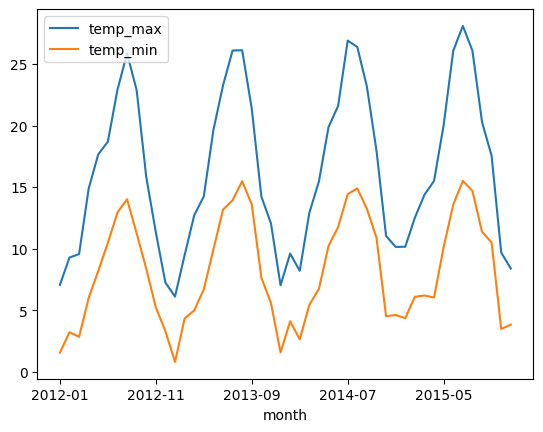

In [12]:
df.groupby("month")[["temp_max","temp_min"]].mean().plot()

In [17]:
#统计一年中最热的天气信息
df["year"]= pd.to_datetime(df["date"]).dt.to_period("Y").astype("str")
df_sort= df.sort_values(["year","temp_max"],ascending=[True,False])

df_sort.drop_duplicates(subset="year")

,date,precipitation,temp_max,temp_min,wind,weather,year
228,2012-08-16,0.0,34.4,18.3,2.8,sun,2012
546,2013-06-30,0.0,33.9,17.2,2.5,sun,2013
953,2014-08-11,0.5,35.6,17.8,2.6,rain,2014
1295,2015-07-19,0.0,35.0,17.2,3.3,sun,2015
